# PULSO — Análise exploratória dos dados

**Equipe Vital Analytics · Turma 1TSCOB · Challenge Oracle + FIAP 2026**

Este notebook documenta a exploração que precedeu as decisões de modelagem.
Ele não faz parte do pipeline de produção (`src/run_pipeline.py`) — serve para
mostrar **como** chegamos às escolhas que estão no código.

Pré-requisito: executar o pipeline ao menos uma vez, para que `data/processed/`
esteja populado.

```bash
python src/run_pipeline.py
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = BASE / "data" / "processed"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

ind  = pd.read_csv(PROC / "mv_indicadores_municipio.csv", dtype={"codigo": str})
fato = pd.read_csv(PROC / "fato_internacao_mes.csv", dtype={"codigo": str})
cid  = pd.read_csv(PROC / "fato_cid_capitulo.csv", dtype={"codigo": str})
uf   = pd.read_csv(PROC / "fato_uf_mes.csv")

print(f"municípios .......... {len(ind):>6}")
print(f"fato mensal ......... {len(fato):>6} linhas")
print(f"perfil CID-10 ....... {len(cid):>6} linhas")
print(f"período ............. {fato.periodo.min()} a {fato.periodo.max()}")

municípios ..........    645
fato mensal .........   3847 linhas
perfil CID-10 .......   5781 linhas
período ............. 2025-07 a 2026-06


## 1. O tamanho do problema

Antes de qualquer modelo, o volume. Estes são os números que a solução precisa
sustentar.

In [2]:
total_intern = ind.internacoes_12m.sum()
total_valor  = ind.valor_total_12m.sum()

print(f"internações em 12 meses ..... {total_intern:>15,.0f}".replace(",", "."))
print(f"recurso executado ........... R$ {total_valor:>12,.0f}".replace(",", "."))
print(f"custo médio por internação .. R$ {total_valor/total_intern:>12,.2f}")
print(f"leitos SUS .................. {ind.leitos_sus.sum():>15,.0f}".replace(",", "."))
print(f"população de referência ..... {ind.populacao.sum():>15,.0f}".replace(",", "."))

internações em 12 meses .....       2.913.953
recurso executado ........... R$ 5.686.834.532
custo médio por internação .. R$     1,951.59
leitos SUS ..................          55.090
população de referência .....      46.081.801


## 2. Primeira descoberta: a maioria dos municípios não tem hospital

Metade dos municípios paulistas não registra nenhuma internação. Isso muda o
desenho da análise: comparar 645 municípios como se fossem equivalentes seria
errado desde o início.

In [3]:
com_rede = (ind.leitos_sus > 0).sum()
com_intern = (ind.internacoes_12m > 0).sum()

print(f"municípios .................. {len(ind)}")
print(f"com leitos SUS .............. {com_rede}  ({com_rede/len(ind):.0%})")
print(f"com internações registradas . {com_intern}  ({com_intern/len(ind):.0%})")

# Concentração: quantos municípios respondem por metade das internações?
ordenado = ind.sort_values("internacoes_12m", ascending=False)
acumulado = ordenado.internacoes_12m.cumsum() / total_intern
n_metade = int((acumulado <= 0.5).sum()) + 1
print(f"\n{n_metade} municípios concentram 50% das internações do estado.")

municípios .................. 645
com leitos SUS .............. 346  (54%)
com internações registradas . 326  (51%)

13 municípios concentram 50% das internações do estado.


## 3. Distribuição da ocupação estimada

A ocupação é o indicador central do painel. Vale olhar a distribuição antes de
definir os limiares de alerta.

**Fórmula:** `(internações × permanência média) ÷ (leitos SUS × 365) × 100`

count    325.0
mean      51.6
std       28.4
min        0.5
25%       27.6
50%       48.4
75%       75.0
max      118.2


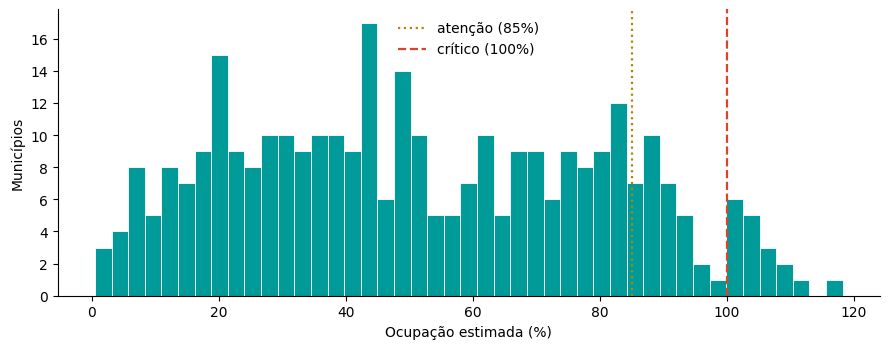

In [4]:
base = ind[(ind.leitos_sus > 0) & (ind.internacoes_12m > 0)].copy()

print(base.ocupacao_estimada_pct.describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(base.ocupacao_estimada_pct.clip(0, 200), bins=45,
        color="#009B98", edgecolor="white", linewidth=.6)
ax.axvline(85,  color="#B5820A", ls=":",  lw=1.6, label="atenção (85%)")
ax.axvline(100, color="#D9452B", ls="--", lw=1.6, label="crítico (100%)")
ax.set_xlabel("Ocupação estimada (%)")
ax.set_ylabel("Municípios")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 4. O problema que quase passou despercebido

Ao ordenar por ocupação, o topo da lista era dominado por municípios pequenos
com permanência média absurdamente alta. Investigando: são sedes de hospital
psiquiátrico e de retaguarda.

Sem tratar isso, o ranking de "rede em colapso" apontaria para lugares onde a
ocupação alta é **estrutural**, não crise — e esconderia os municípios que de
fato precisam de ação.

In [5]:
print("Municípios com permanência média acima de 20 dias:\n")
print(base.nlargest(6, "media_permanencia")[
    ["municipio", "populacao", "leitos_sus", "internacoes_12m",
     "media_permanencia", "ocupacao_estimada_pct"]
].to_string(index=False))

print("\nDistribuição da permanência média (dias):")
print(base.media_permanencia.describe().round(2).to_string())

Municípios com permanência média acima de 20 dias:



                 municipio  populacao  leitos_sus  internacoes_12m  media_permanencia  ocupacao_estimada_pct
                      Jaci       7944         173              701              97.99                  108.8
                   Itapira      74038         381             5862              25.18                  106.1
                     Garça      43081         221             2684              24.21                   80.6
  Espírito Santo do Pinhal      40610         298             4622              23.76                  101.0
          Campos do Jordão      47956         185             2801              19.79                   82.1
Santa Rita do Passa Quatro      24996         250             1727              18.65                   35.3

Distribuição da permanência média (dias):
count    325.00
mean       4.64
std        5.95
min        0.91
25%        2.98
50%        3.76
75%        4.73
max       97.99


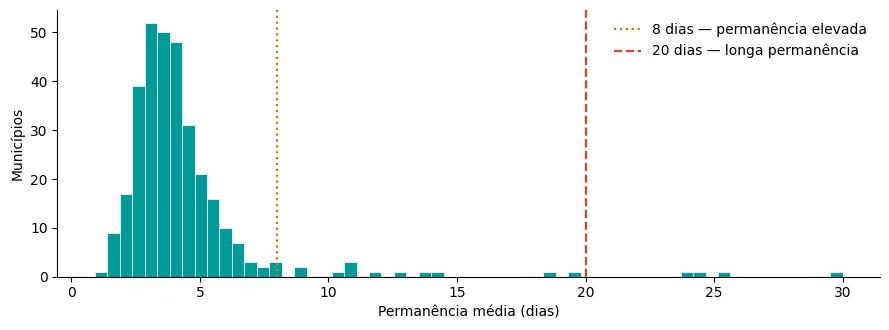

acima de  8 dias:  18 municípios
acima de 20 dias:   4 municípios


In [6]:
# Onde cortar? A permanência de hospital de agudos gira em torno de 4 a 5 dias.
# O corte precisa separar retaguarda de hospital geral complexo.
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(base.media_permanencia.clip(0, 30), bins=60,
        color="#009B98", edgecolor="white", linewidth=.5)
ax.axvline(8,  color="#B5820A", ls=":",  lw=1.6, label="8 dias — permanência elevada")
ax.axvline(20, color="#D9452B", ls="--", lw=1.6, label="20 dias — longa permanência")
ax.set_xlabel("Permanência média (dias)")
ax.set_ylabel("Municípios")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for corte in (8, 20):
    n = (base.media_permanencia >= corte).sum()
    print(f"acima de {corte:>2} dias: {n:>3} municípios")

**Decisão tomada:** excluir dos modelos de capacidade apenas os municípios com
permanência **≥ 20 dias**.

O corte em 8 dias foi testado e descartado: ele removia hospitais gerais de
maior complexidade — Guarulhos, com 8,2 dias, é exatamente o tipo de rede que o
gestor precisa monitorar. Excluí-lo esconderia parte relevante do problema.

## 5. Perfil assistencial: o que ocupa o leito paulista

In [7]:
perfil = (cid.groupby("capitulo_cid10").internacoes.sum()
             .sort_values(ascending=False))
part = (perfil / perfil.sum() * 100).round(1)

resumo = pd.DataFrame({"internacoes": perfil, "participacao_pct": part})
print(resumo.head(8).to_string())
print(f"\nOs 3 primeiros capítulos concentram {part.head(3).sum():.1f}% da demanda.")

                                                  internacoes  participacao_pct
capitulo_cid10                                                                 
XV. Gravidez, parto e puerpério                        369140              12.7
XI. Doenças do aparelho digestivo                      335379              11.5
IX. Doenças do aparelho circulatório                   322222              11.1
XIX. Lesões e envenenamentos por causas externas       310374              10.7
II. Neoplasias (tumores)                               259940               8.9
X. Doenças do aparelho respiratório                    256533               8.8
XIV. Doenças do aparelho geniturinário                 252030               8.6
I. Doenças infecciosas e parasitárias                  125599               4.3

Os 3 primeiros capítulos concentram 35.3% da demanda.


Gravidez e parto lidera. Isso não é acaso nem erro de dado: é a assinatura
estatística do sistema hospitalar brasileiro, e aponta onde a atenção primária
tem maior potencial de desafogar o leito.

## 6. Oferta versus pressão — a relação que motivou o agrupamento

Se ocupação alta fosse simplesmente falta de leito, haveria correlação negativa
forte entre oferta e ocupação. Não há.

correlação entre oferta de leitos e ocupação: -0.001


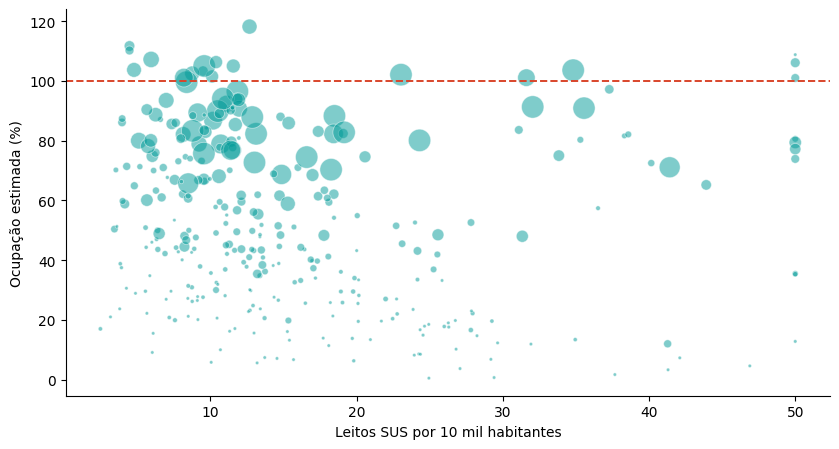

In [8]:
corr = base[["leitos_sus_10k_hab", "ocupacao_estimada_pct"]].corr().iloc[0, 1]
print(f"correlação entre oferta de leitos e ocupação: {corr:.3f}")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.scatter(base.leitos_sus_10k_hab.clip(0, 50), base.ocupacao_estimada_pct.clip(0, 140),
           s=np.clip(base.internacoes_12m / 120, 6, 260),
           color="#009B98", alpha=.5, edgecolor="white", linewidth=.6)
ax.axhline(100, color="#D9452B", ls="--", lw=1.4)
ax.set_xlabel("Leitos SUS por 10 mil habitantes")
ax.set_ylabel("Ocupação estimada (%)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

A nuvem não tem forma de reta. Existem municípios com **muitos** leitos por
habitante **e** ocupação alta — são polos regionais, que atendem a população de
toda a microrregião, não só a própria.

É exatamente esse padrão que justifica o **K-Means**: agrupar por comportamento
observado em vez de comparar por porte populacional, que junta realidades
opostas sob o mesmo rótulo.

## 7. Tendência: separando crescimento de ruído

Ajustar uma reta em 12 pontos é fácil. O difícil é saber quando a reta significa
alguma coisa.

In [9]:
tend = pd.read_csv(PROC / "mv_tendencia_municipio.csv", dtype={"codigo": str})

print(f"séries ajustadas ................ {len(tend)}")
print(f"R² mediano do conjunto .......... {tend.r2.median():.3f}")
print(f"com R² >= 0,4 ................... {(tend.r2 >= 0.4).sum()}")
print(f"com R² >= 0,5 ................... {(tend.r2 >= 0.5).sum()}")

print("\nSem filtro de R² — o topo do ranking:")
print(tend.nlargest(5, "variacao_anualizada_pct")[
    ["municipio", "internacoes_12m", "variacao_anualizada_pct", "r2"]
].to_string(index=False))

print("\nCom filtro R² >= 0,4 — o que sobra:")
print(tend[tend.r2 >= 0.4].nlargest(5, "variacao_anualizada_pct")[
    ["municipio", "internacoes_12m", "variacao_anualizada_pct", "r2"]
].to_string(index=False))

séries ajustadas ................ 265
R² mediano do conjunto .......... 0.069
com R² >= 0,4 ................... 28
com R² >= 0,5 ................... 20

Sem filtro de R² — o topo do ranking:
            municipio  internacoes_12m  variacao_anualizada_pct    r2
        Guaratinguetá            10111                    119.4 0.712
             Paulínia             5293                    111.1 0.549
           Valparaíso             1093                     88.0 0.622
Santa Rosa de Viterbo             1114                     49.2 0.623
            Cerquilho             1004                     47.5 0.141

Com filtro R² >= 0,4 — o que sobra:
            municipio  internacoes_12m  variacao_anualizada_pct    r2
        Guaratinguetá            10111                    119.4 0.712
             Paulínia             5293                    111.1 0.549
           Valparaíso             1093                     88.0 0.622
Santa Rosa de Viterbo             1114                     49.2 0.623
  

A diferença entre as duas listas é o argumento. Um município com `+48%` e R²
`0,14` está oscilando em torno da média — apresentá-lo como "o que mais cresce"
seria erro de leitura, não de cálculo.

**Decisão tomada:** o painel filtra por R² ≥ 0,4 em todo lugar onde apresenta
tendência.

## 8. Contexto nacional

São Paulo isolado não diz muito. Comparado ao país, dimensiona o problema.

In [10]:
nacional = uf.groupby("uf").internacoes.sum().sort_values(ascending=False)
total_br = nacional.sum()

print(f"internações no Brasil (12 meses): {total_br:,.0f}".replace(",", "."))
print(f"participação de São Paulo: {nacional.iloc[0]/total_br:.1%}\n")
print(nacional.head(8).to_string())

internações no Brasil (12 meses): 14.563.534
participação de São Paulo: 20.0%

uf
São Paulo            2913953
Minas Gerais         1579017
Paraná               1102215
Bahia                 973130
Rio de Janeiro        933178
Rio Grande do Sul     878506
Santa Catarina        699385
Pernambuco            673057


## 9. O que esta exploração definiu

| Descoberta | Decisão de projeto |
|---|---|
| Metade dos municípios não tem rede hospitalar | Modelos rodam só sobre municípios com leitos e internações |
| Permanência média varia de 3 a 98 dias | Corte em 20 dias separa retaguarda de hospital de agudos |
| Oferta e ocupação não são correlacionadas | K-Means em vez de comparação por porte populacional |
| R² mediano das séries é baixo | Filtro de R² ≥ 0,4 antes de afirmar tendência |
| 3 capítulos CID concentram 35% da demanda | Perfil assistencial vira uma das perguntas do painel |

Todas essas decisões estão implementadas em `src/etl/transform.py` e
`src/analytics/modelos.py`, com o raciocínio registrado em comentário no
próprio código.